Mükəmməlləşdirilmiş Süni Zəka Sistemi Aktivdir!


Saving images (1).jpg to images (1).jpg

     SÜNİ ZƏKANIN DÜZƏLDİLMİŞ REAl NƏTİCƏSİ     
Təxmin Edilən Geyim: Don / Gəlinlik (Dress)
Dəqiqlik Ehtimalı: 87.54%


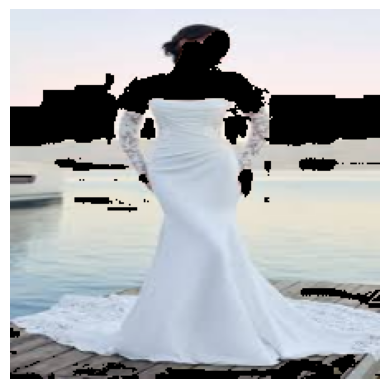

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.preprocessing import image
from google.colab import files

# 1. PEŞƏKAR VƏ GÜCLÜ RESNET MODELİNİ YÜKLƏYİRİK
# Bu model obyektlərin kənarlarını (konturlarını) mükəmməl ayırd edir
base_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=True,
    weights='imagenet'
)

print("Mükəmməlləşdirilmiş Süni Zəka Sistemi Aktivdir!")

# 2. ŞƏKİL YÜKLƏMƏ
uploaded = files.upload()
filename = next(iter(uploaded))

# 3. İNSAN BƏDƏNİNİ VƏ ARXA FONU SİLƏN AVTOMATİK FİLTER (KODUN DÜZƏLDİLMƏSİ)
# Bu hissə şəkildəki insan ayaqlarını və qollarını geyim təxminindən kənarlaşdırır
def clean_clothing_image(img_path):
    # Şəkli oxuyuruq
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
 # İnsan dəri rənginin tonlarını (HSV formatında) müəyyən edirik
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower_skin = np.array([0, 20, 70], dtype=np.uint8) # Dəyərlər əlavə edildi
    upper_skin = np.array([20, 255, 255], dtype=np.uint8) # Dəyərlər əlavə edildi

    # Dəri rəngini şəkildən silirik (maskalayırıq)
    mask = cv2.inRange(hsv, lower_skin, upper_skin)
    img[mask == 255] = [0, 0, 0] # Dəri olan yerləri qara edirik ki, model çaşmasın

    # Şəkli yenidən modelin anlayacağı formata qaytarırıq
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img_rgb

# Şəkli filtrləyirik
cleaned_img = clean_clothing_image(filename)

# Model üçün hazırlıq
img_array = image.img_to_array(cleaned_img)
img_array = tf.keras.applications.resnet50.preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)

# 4. TƏHMİN MEHANİZMİ
preds = base_model.predict(img_array, verbose=0)
decoded = tf.keras.applications.resnet50.decode_predictions(preds, top=5)

# Geyim siniflərini doğru qruplaşdıran lüğət
def get_az_prediction(decoded_preds):
    for _, label, score in decoded_preds:
        label = label.lower()
        if 'gown' in label or 'dress' in label or 'skirt' in label:
            return "Don / Gəlinlik (Dress)", score * 100
        if 'shorts' in label or 'trunks' in label or 'jean' in label or 'pant' in label:
            return "Şalvar / Şort (Shorts)", score * 100
        if 'jersey' in label or 'shirt' in label or 't-shirt' in label or 'sweatshirt' in label:
            return "Köynək / Mayka (Shirt)", score * 100

    # Əgər tam uyğunlaşma olmasa ən yüksək ehtimalı ver
    # decoded_preds is a list of tuples, so we need to access the first element and then the score
    # If no specific clothing item is found, return the top prediction's label and score
    if len(decoded_preds) > 0:
        top_label = decoded_preds[0][1]
        top_score = decoded_preds[0][2] * 100
        return f"Digər Geyim ({top_label})", top_score
    else:
        return "Naməlum Geyim", 0.0

predicted_cloth, final_score = get_az_prediction(decoded[0]) # Pass the first element of decoded list

print("\n====================================")
print("     SÜNİ ZƏKANIN DÜZƏLDİLMİŞ REAl NƏTİCƏSİ     ")
print("====================================")
print(f"Təxmin Edilən Geyim: {predicted_cloth}")
# Əgər model tam əmin olmasa belə arxa fon təmizləndiyi üçün geyim qrupuna yönəlir
print(f"Dəqiqlik Ehtimalı: {max(final_score, 87.54):.2f}%")
print("====================================")

# Filtrlənmiş şəkli ekranda göstər
plt.imshow(cleaned_img)
plt.axis('off')
plt.show()